1. Suppose the time step value is  42 . Modify the code for creating the two time embeddings to create two time embeddings with embedding dimensions  512  and  256 , respectively. Then, print out the shape of the two time embeddings.

In [23]:
from torch import nn
class EmbedLayer(nn.Module):
    def __init__(self, input_dim, emb_dim):    #The input and embedding dimensions are input_dim and emb_dim, respectively
        super().__init__()
        self.input_dim = input_dim
        layers = [nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),]    #The input goes through the two linear layers, with a GELU activation in between
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [24]:
import torch

timeembed1=EmbedLayer(1, 512)    #Instantiates two time embedding blocks, with embedding dimensions 512 and 256
timeembed2=EmbedLayer(1, 256)

timesteps=torch.tensor([42]).long()    #aici-------------------------------------------------------------
t=timesteps/1000
temb1 = timeembed1(t).view(-1, 512, 1, 1)
temb2 = timeembed2(t).view(-1, 256, 1, 1)
print("the shape of the first time embedding is", temb1.shape)    #Prints out the shape of the two time embeddings
print("the shape of the second time embedding is", temb2.shape)

the shape of the first time embedding is torch.Size([1, 512, 1, 1])
the shape of the second time embedding is torch.Size([1, 256, 1, 1])


2. Suppose there are four labels in the batch with values  1,3,5,  and  7 , respectively. Modify the code for generating label embeddings to create two label embeddings. Then, print out the shape of the two label embeddings.

In [25]:
n_classes=10
contextembed1=EmbedLayer(n_classes, 512)    #Instantiates two label embedding blocks
contextembed2=EmbedLayer(n_classes, 256)
label=torch.tensor([1,3,5,7]).long()    #aici--------------------------------------------------------------------------------
context_mask = torch.bernoulli(
    torch.zeros_like(label)+0.1)    #Generates a mask to hide the label with a 10% probability
onehot = torch.nn.functional.one_hot(label,
            num_classes=n_classes).type(torch.float)    #Converts each label to a one-hot tensor with ten values
context_mask = context_mask[:, None]
context_mask = context_mask.repeat(1,n_classes)
context_mask = (-1*(1-context_mask))
c = onehot * context_mask
cemb1 = contextembed1(c).view(-1, 512, 1, 1)
cemb2 = contextembed2(c).view(-1, 256, 1, 1)
print("the shape of the first label embedding is", cemb1.shape)
print("the shape of the second label embedding is", cemb2.shape)

the shape of the first label embedding is torch.Size([4, 512, 1, 1])
the shape of the second label embedding is torch.Size([4, 256, 1, 1])


3. Generate  40  images by setting the guidance parameter to  1 . Then, plot the generated images in a  4×10  grid.

In [26]:
class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, is_res = False):
        super().__init__()
        self.same_channels = in_channels==out_channels
        self.is_res = is_res
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),)
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),)
    def forward(self, x):
        if self.is_res:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            if self.same_channels:
                out = x + x2
            else:
                out = x1 + x2
            return out / 1.414
        else:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            return x2

In [27]:
class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        layers = [ResidualConvBlock(in_channels,
                out_channels), nn.MaxPool2d(2)] #The down block consists of a residual convolutional block and a 2D max pooling layer
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

In [28]:
class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_channels,
                                     out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels),] #The up block consists of two residual convolutional blocks and a 2D transposed convolutional layer
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

In [29]:
class Unet(nn.Module):
    def __init__(self, in_channels, n_feat = 256, n_classes=10):
        super().__init__()
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_classes = n_classes
        self.init_conv = ResidualConvBlock(in_channels,
                               n_feat, is_res=True)
        self.down1 = UnetDown(n_feat, n_feat)
        self.down2 = UnetDown(n_feat, 2 * n_feat)
        self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.timeembed1 = EmbedLayer(1, 2*n_feat)
        self.timeembed2 = EmbedLayer(1, 1*n_feat)
        self.contextembed1 = EmbedLayer(n_classes, 2*n_feat)
        self.contextembed2 = EmbedLayer(n_classes, 1*n_feat)
        self.up0=nn.Sequential(nn.ConvTranspose2d(2*n_feat,2*n_feat,7,7),
            nn.GroupNorm(8, 2 * n_feat),nn.ReLU(),)
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)
        self.out = nn.Sequential(nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1),)
    def forward(self, x, c, t, context_mask):
        x = self.init_conv(x)
        down1 = self.down1(x)
        down2 = self.down2(down1)
        hiddenvec = self.to_vec(down2) #The input images first go through multiple down blocks and then the bottleneck
        c=nn.functional.one_hot(c,num_classes=self.n_classes).type(torch.float)
        context_mask = context_mask[:, None]
        context_mask = context_mask.repeat(1,self.n_classes)
        context_mask = (-1*(1-context_mask))
        c = c * context_mask #The labels are masked with a 10% probability, so the model acts both as an unconditional model and a conditional model
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1) #Label and time embeddings are used in up blocks
        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1+ temb1, down2)
        up3 = self.up2(cemb2*up2+ temb2, down1) #Skip connections are used to merge features from contracting and expansive paths
        out = self.out(torch.cat((up3, x), 1))
        return out

In [30]:
def noise_scheduler(T):
    beta1, beta2 = 0.0001, 0.02
    beta_t = (beta2 - beta1) * torch.arange(0, T + 1,
                    dtype=torch.float32) / T + beta1
    sqrt_beta_t = torch.sqrt(beta_t)
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
    sqrtab = torch.sqrt(alphabar_t)
    oneover_sqrta = 1 / torch.sqrt(alpha_t)
    sqrtmab = torch.sqrt(1 - alphabar_t)
    mab_over_sqrtmab_inv = (1 - alpha_t) / sqrtmab
    return {"alpha_t": alpha_t,  # \alpha_t
        "oneover_sqrta": oneover_sqrta,  # 1/\sqrt{\alpha_t}
        "sqrt_beta_t": sqrt_beta_t,  # \sqrt{\beta_t}
        "alphabar_t": alphabar_t,  # \bar{\alpha_t}
        "sqrtab": sqrtab,  # \sqrt{\bar{\alpha_t}}
        "sqrtmab": sqrtmab,  # \sqrt{1-\bar{\alpha_t}}
        # (1-\alpha_t)/\sqrt{1-\bar{\alpha_t}}
        "mab_over_sqrtmab": mab_over_sqrtmab_inv,}

In [31]:
device="cuda" if torch.cuda.is_available() else "cpu"
class DDPM(nn.Module):
    def __init__(self, model, n_T, device=device, drop_prob=0.1):
        super().__init__()
        self.model = model.to(device)
        for k, v in noise_scheduler(n_T).items():
            self.register_buffer(k, v)
        self.n_T = n_T
        self.device = device
        self.drop_prob = drop_prob
        self.loss_mse = nn.MSELoss()
    def forward(self, x, c):
        _ts=torch.randint(1,self.n_T+1,(x.shape[0],)).to(self.device) #Randomly generates time steps between 1 and 1,000
        noise = torch.randn_like(x)
        x_t = (self.sqrtab[_ts, None, None, None] * x
            + self.sqrtmab[_ts, None, None, None] * noise) #Generates noisy images as the weighted sum of clean images and noise
        context_mask = torch.bernoulli(torch.zeros_like(c)+
                                   self.drop_prob).to(self.device)
        return self.loss_mse(noise,
                 self.model(x_t, c, _ts / self.n_T, context_mask)) #The output is the mean squared error between the actual noise and the predicted noise

In [32]:
import numpy as np

@torch.no_grad()
def sample(ddpm, model, n_sample, size, device,
           guide_w = 0.0, step_size=1):
    x_i = torch.randn(n_sample, *size).to(device)
    c_i = torch.arange(0,10).to(device) #The class labels have values 0 to 9, so we generate 10 different types of images
    c_i = c_i.repeat(int(n_sample/c_i.shape[0]))
    context_mask = torch.zeros_like(c_i).to(device)
    c_i = c_i.repeat(2)
    context_mask = context_mask.repeat(2)
    context_mask[n_sample:] = 1. #The first half of the mask is turned off as 0s, and the second half is turned on as 1s
    x_i_store = []
    for i in range(ddpm.n_T, 0, -step_size):
        t_is = torch.tensor([i / ddpm.n_T]).to(device)
        t_is = t_is.repeat(n_sample,1,1,1)
        x_i = x_i.repeat(2,1,1,1)
        t_is = t_is.repeat(2,1,1,1)
        z = torch.randn(n_sample,*size).to(device) if i>1 else 0
        eps = model(x_i, c_i, t_is, context_mask)
        eps1 = eps[:n_sample] #Generates a set of images using the conditional model
        eps2 = eps[n_sample:] #Generates a set of images using the unconditional model
        eps = (1+guide_w)*eps1 - guide_w*eps2 #The final output is a weighted sum of conditional and unconditional generation
        x_i = x_i[:n_sample]
        x_i = (ddpm.oneover_sqrta[i] * (x_i -
                    eps * ddpm.mab_over_sqrtmab[i])
            + ddpm.sqrt_beta_t[i] * z)
        if i%20==0 or i==ddpm.n_T or i<8:
            x_i_store.append(x_i.detach().cpu().numpy())
    x_i_store = np.array(x_i_store)
    return x_i, x_i_store

In [33]:
from torchvision import transforms, datasets

torch.manual_seed(42)
tf = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Lambda(lambda x: 2*(x-0.5)),])    #Converts raw image data into PyTorch tensors with values between −1 and 1
dataset = datasets.FashionMNIST(
    r".",
    train=True,
    download=True,
    transform=tf,)    #Downloads the training dataset using the TorchVision library

In [34]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

In [35]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [36]:
n_epoch = 20
n_T = 1000
device="cuda" if torch.cuda.is_available() else "cpu"
n_classes = 10
n_feat = 256
lrate=0.00001
model=Unet(in_channels=1,
           n_feat=n_feat,
           n_classes=n_classes)    #Creates a U-Net model by instantiating the Unet class
ddpm=DDPM(model, n_T=n_T).to(device)    #Creates a DDPM to help train the U-Net model
optim = torch.optim.Adam(ddpm.parameters(), lr=lrate)

In [37]:
model.load_state_dict(torch.load("files/conditional.pth",
            weights_only=True,
            map_location=device))    #Loads trained model parameters
x,c=next(iter(dataloader))
x,c=x.to(device),c.to(device)
ddpm.eval()
n_sample = n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
            device,guide_w=2)    #Generates 10 images using the trained model
x_real = torch.Tensor(x_gen.shape).to(device)    #Selects 10 real images for comparison
for k in range(n_classes):
    try:
        idx = torch.squeeze((c == k).nonzero())[0]
    except:
        idx = 0
    x_real[k] = x[idx]
x_all = torch.cat([x_gen, x_real])


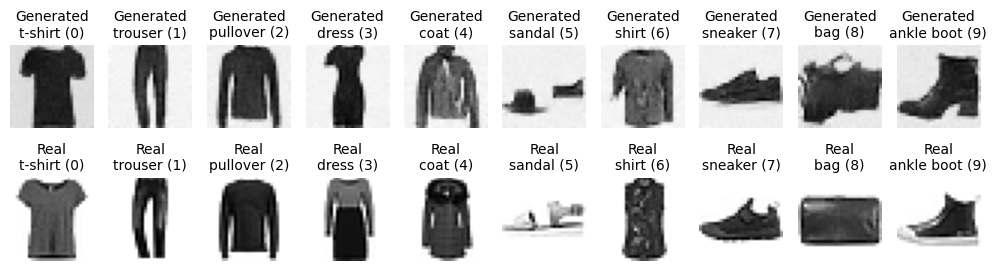

In [38]:
captions=[]
for i in range(20):
    gen="Generated" if i<10 else "Real"
    num=i%10
    label_and_num=f"{gen}\n{text_labels[num]} ({num})"
    captions.append(label_and_num) #Creates a description for each image

from matplotlib import pyplot as plt

plt.figure(figsize=(10,3),dpi=100)
for i in range(20): #Plots the generated images on top and the real images at the bottom
    plt.subplot(2,10,i+1)
    plt.imshow(x_all[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    plt.title(captions[i],fontsize=10)
plt.tight_layout()
plt.show()

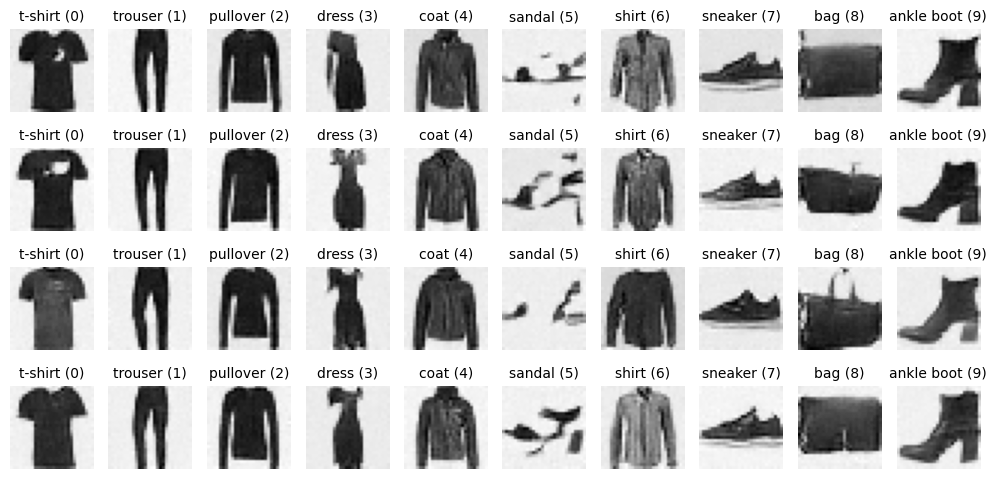

In [39]:
#3 min
n_sample  = 4*n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
                              device,guide_w=5)    #Generates 40 images by setting the guidance parameter to 5
plt.figure(figsize=(10,5),dpi=100)
for i in range(40):    #Plots the generated images in a 4 × 10 grid
    plt.subplot(4,10,i+1)
    plt.imshow(x_gen[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    c=i%10
    plt.title(f"{text_labels[c]} ({c})",fontsize=10)
plt.tight_layout()
plt.show()
